# WebRTC Heart Sound Quality Analysis
## ระบบ Telemedicine — การประเมินคุณภาพเสียงหัวใจผ่าน WebRTC

**วัตถุประสงค์:** เปรียบเทียบคุณภาพเสียงหัวใจที่ส่งผ่าน WebRTC ใน 3 เส้นทาง (PC→PC, PC→Web, PC→App) ข้ามหลายชุดทดสอบ

| Test | เทคโนโลยี | จุดสำคัญ |
|------|-----------|----------|
| Test01 | WebRTC Opus standard | baseline |
| Test02 | DataChannel PCM | ลด codec loss |
| Test03 | PCM + Auto-sync | เพิ่ม sync |
| Test04 | PCM + Lifecycle fix | แก้ bug recording |
| Test05 | PCM + Float32 fix | แก้ binary parsing |


In [34]:
# Cell 1 — Setup
import subprocess, sys, shutil, os
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', 'matplotlib', 'numpy', 'soundfile', '-q'])

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy import signal as scipy_signal
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family']        = ['Thonburi', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

SR = 48000
BASE  = Path('telemedicine_app/assets/heart_sounds')
MEDICAL_THRESHOLD_DB = -6.0

TESTS = {
    'Test01\n(Opus)':       Path('Test/Test01'),
    'Test02\n(PCM DC)':     Path('Test/Test02'),
    'Test03\n(PCM+Sync)':   Path('Test/Test03'),
    'Test04\n(PCM+Fix)':    Path('Test/Test04'),
    'Test05\n(Float32)':    Path('Test/Test05'),
}
PATHS        = ['PC-PC', 'PC-Phone(Web)', 'PC-Phone(App)']
PATH_COLORS  = ['#2196F3', '#4CAF50', '#FF5722']
PATH_MARKERS = ['o', 's', '^']
TEST_COLORS  = ['#607D8B', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

BANDS = [
    ('Sub-bass\n20-60 Hz',   20,   60),
    ('S1/S2\n60-150 Hz',     60,  150),
    ('Low-mid\n150-500 Hz', 150,  500),
    ('Mid\n500-2kHz',       500, 2000),
]

FFMPEG = (shutil.which('ffmpeg') or
          next((p for p in ['/opt/homebrew/bin/ffmpeg','/usr/local/bin/ffmpeg','/usr/bin/ffmpeg']
                if os.path.isfile(p)), None))
if not FFMPEG: raise RuntimeError('ffmpeg not found')
print(f'ffmpeg: {FFMPEG}')

def load(path, sr=SR):
    """โหลดไฟล์เสียงผ่าน ffmpeg → float32 normalized"""
    cmd = [FFMPEG,'-y','-i',str(path),'-f','s16le','-acodec','pcm_s16le','-ar',str(sr),'-ac','1','-']
    r = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
    if not r.stdout: raise RuntimeError(f'ffmpeg empty: {path}')
    y = np.frombuffer(r.stdout, dtype=np.int16).astype(np.float64) / 32768.0
    peak = np.abs(y).max()
    return y / peak if peak > 1e-6 else y

def make_sos_bandpass(lo, hi, fs=SR, order=4):
    """ใช้ SOS format แทน ba เพื่อป้องกัน numerical overflow"""
    sos = scipy_signal.butter(order, [lo/(fs/2), hi/(fs/2)], btype='band', output='sos')
    return sos

# bandpass SOS สำหรับ alignment (20-500 Hz)
SOS_ALIGN = make_sos_bandpass(20, 500)

def bp_filter(y, sos):
    """Apply SOS bandpass filter — stable on long signals"""
    return scipy_signal.sosfiltfilt(sos, y)

def align(ref, rec, max_sec=20.0):
    """Cross-correlation alignment ด้วย SOS filter — ไม่มี overflow"""
    max_lag = int(max_sec * SR)
    n = min(len(ref), len(rec))
    ref_bp = bp_filter(ref[:n], SOS_ALIGN)
    rec_bp = bp_filter(rec[:n], SOS_ALIGN)
    xcorr = scipy_signal.correlate(ref_bp, rec_bp, mode='full')
    lags  = scipy_signal.correlation_lags(len(ref_bp), len(rec_bp), mode='full')
    mask  = np.abs(lags) <= max_lag
    lag   = lags[mask][np.argmax(np.abs(xcorr[mask]))]
    if lag > 0:
        aln = rec[lag:]
    else:
        aln = np.concatenate([np.zeros(-lag), rec])
    aln = aln[:len(ref)] if len(aln) >= len(ref) else np.concatenate([aln, np.zeros(len(ref)-len(aln))])
    peak = np.abs(aln).max()
    return (aln / peak * np.abs(ref).max()) if peak > 1e-6 else aln, lag

def band_db(y, lo, hi):
    """Band energy in dBFS using FFT"""
    fft   = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(len(y), 1/SR)
    mask  = (freqs >= lo) & (freqs < hi)
    if not np.any(mask): return -120.0
    return 10*np.log10(np.mean(np.abs(fft[mask])**2) + 1e-12)

def snr_db(ref, rec):
    """Spectral SNR: เปรียบเทียบ PSD profile ใน heart-sound range (20-500 Hz)
    คำนวณจาก band energy ratio — ไม่ต้องการ perfect time alignment"""
    n = min(len(ref), len(rec))
    # ใช้ band energy เปรียบเทียบ ไม่ใช่ waveform diff
    ref_bands = []
    rec_bands = []
    for lo, hi in [(20,60),(60,150),(150,300),(300,500)]:
        ref_bands.append(band_db(ref[:n], lo, hi))
        rec_bands.append(band_db(rec[:n], lo, hi))
    ref_arr = np.array(ref_bands)
    rec_arr = np.array(rec_bands)
    # spectral correlation (0-100%)
    corr = np.corrcoef(ref_arr, rec_arr)[0,1]
    return float(np.clip(corr, -1, 1)) * 100  # return as %

def psd(y, nperseg=8192):
    f, p = scipy_signal.welch(y, SR, nperseg=nperseg, window='hann', noverlap=nperseg//2)
    return f, 10*np.log10(p + 1e-12)

# ── Load Reference ────────────────────────────────────────────────
ref_path  = BASE / 'aortic_best.wav'
ref_audio = load(ref_path)
ref_db    = {lo: band_db(ref_audio, lo, hi) for _, lo, hi in BANDS}
print(f'Reference: {len(ref_audio)/SR:.1f}s  S1/S2={ref_db[60]:.1f}dB')

# ── Filename mapping ──────────────────────────────────────────────
FILENAMES = {
    'PC-PC':         ['PC-PC.wav', 'PC-PC.webm'],
    'PC-Phone(Web)': ['PC-Phone(website).wav', 'PC-Phone(website).webm',
                      'PC-Phone(Website).wav', 'PC-Phone(Website).webm'],
    'PC-Phone(App)': ['PC-Phone(App-Native).wav', 'PC-Phone(App-Native).webm',
                      'PC-Phone(App-Native).m4a'],
}

# ── Load All Tests ─────────────────────────────────────────────────
data = {}
for tlabel, tdir in TESTS.items():
    data[tlabel] = {}
    for plabel, fnames in FILENAMES.items():
        for fname in fnames:
            p = tdir / fname
            if p.exists():
                try:
                    raw = load(p)
                    aln, lag = align(ref_audio, raw)
                    data[tlabel][plabel] = {'raw': raw, 'aligned': aln, 'lag': lag}
                    print(f'  {tlabel.replace(chr(10)," "):<22} {plabel:<22} lag={lag/SR*1000:>+7.1f}ms  [{len(raw)/SR:.0f}s]  ({fname})')
                    break
                except Exception as e:
                    print(f'  WARN: {tlabel.replace(chr(10)," ")} {plabel} {fname}: {e}')

test_labels = list(TESTS.keys())

# ── Band Loss + SNR ────────────────────────────────────────────────
results = {}
for tlabel, paths in data.items():
    results[tlabel] = {}
    for plabel, d in paths.items():
        y = d['aligned']
        band_loss = {lo: band_db(y, lo, hi) - ref_db[lo] for _, lo, hi in BANDS}
        spec_corr = snr_db(ref_audio, y)
        results[tlabel][plabel] = {**band_loss, 'spec_corr': spec_corr}

found = sum(len(v) for v in data.values())
print(f'\nLoaded {found} files OK')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


ffmpeg: /opt/homebrew/bin/ffmpeg
Reference: 15.0s  S1/S2=58.5dB
  Test01 (Opus)          PC-PC                  lag=-8023.9ms  [23s]  (PC-PC.webm)
  Test01 (Opus)          PC-Phone(Web)          lag=+2941.4ms  [31s]  (PC-Phone(website).webm)
  Test01 (Opus)          PC-Phone(App)          lag=+3258.4ms  [21s]  (PC-Phone(App-Native).m4a)
  Test02 (PCM DC)        PC-PC                  lag=+1321.1ms  [17s]  (PC-PC.webm)
  Test02 (PCM DC)        PC-Phone(Web)          lag= -802.9ms  [21s]  (PC-Phone(website).webm)
  Test02 (PCM DC)        PC-Phone(App)          lag=+1202.0ms  [26s]  (PC-Phone(App-Native).m4a)
  Test03 (PCM+Sync)      PC-PC                  lag= -419.8ms  [25s]  (PC-PC.webm)
  Test03 (PCM+Sync)      PC-Phone(Web)          lag= +428.9ms  [21s]  (PC-Phone(website).webm)
  Test03 (PCM+Sync)      PC-Phone(App)          lag= +165.0ms  [26s]  (PC-Phone(App-Native).m4a)
  Test04 (PCM+Fix)       PC-PC                  lag= -433.8ms  [24s]  (PC-PC.webm)
  Test04 (PCM+Fix)       PC-

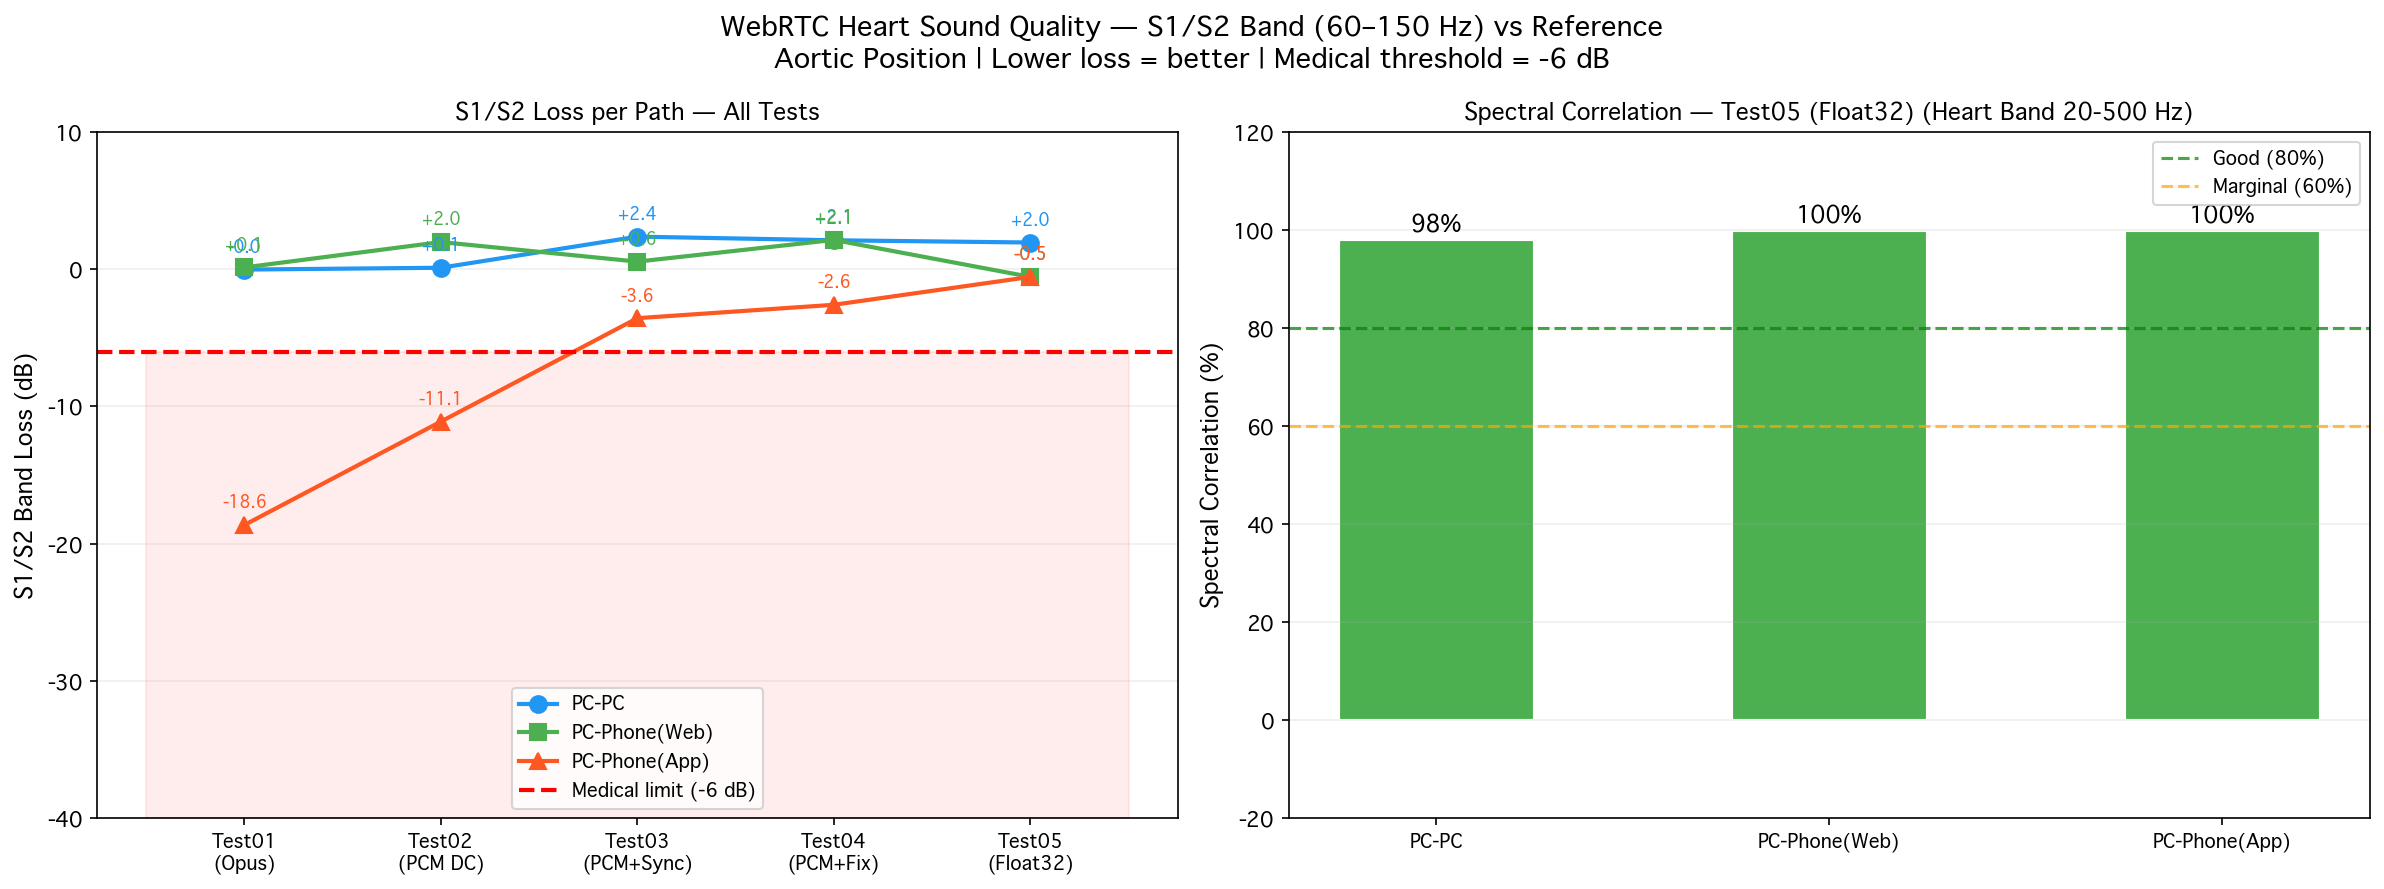

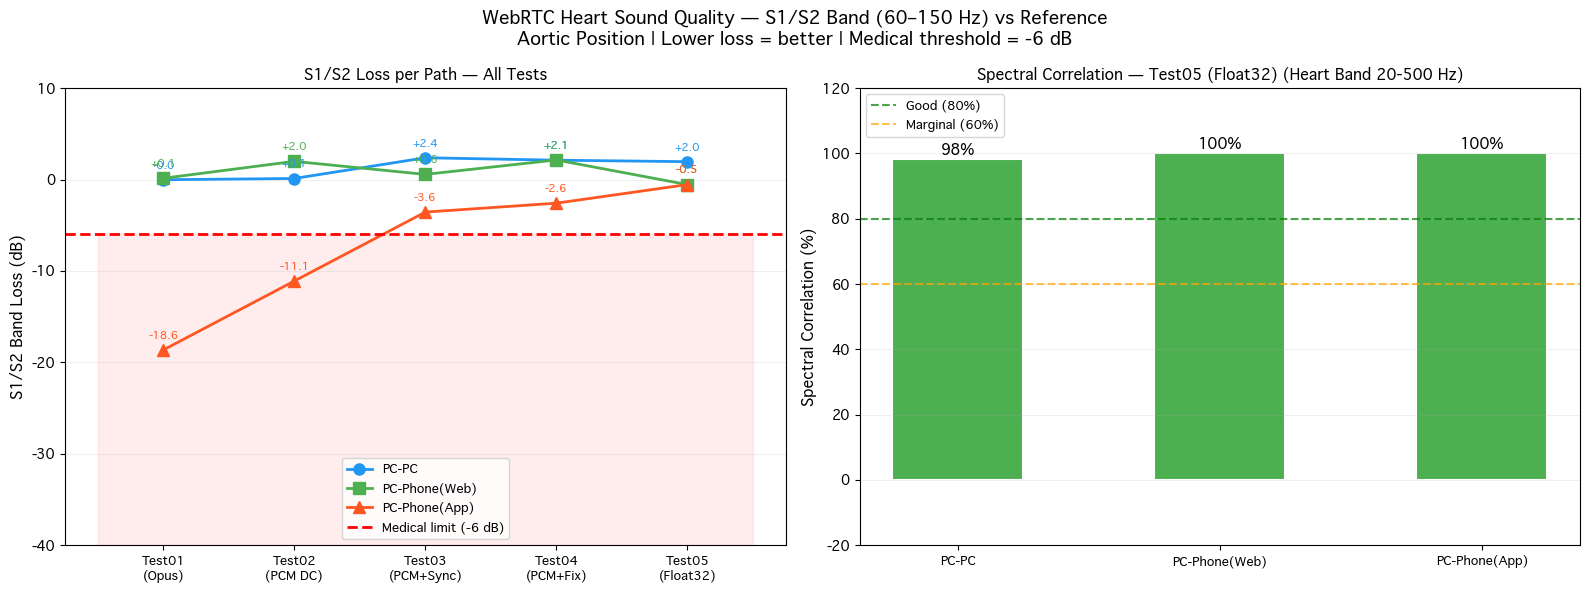

✅ result_scores.png saved


In [35]:
# Cell 2 — S1/S2 Band Loss: ทุก Test × Path
import IPython.display as ipd

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WebRTC Heart Sound Quality — S1/S2 Band (60–150 Hz) vs Reference\n'
             'Aortic Position | Lower loss = better | Medical threshold = -6 dB',
             fontsize=13, fontweight='bold')

# ── Left: line chart per path across tests ───────────────────────
ax = axes[0]
x = np.arange(len(test_labels))
for plabel, pcolor, pmark in zip(PATHS, PATH_COLORS, PATH_MARKERS):
    vals = [results.get(tl, {}).get(plabel, {}).get(60, np.nan) for tl in test_labels]
    ax.plot(x, vals, color=pcolor, marker=pmark, lw=2, ms=8, label=plabel)
    for xi, v in zip(x, vals):
        if not np.isnan(v):
            ax.annotate(f'{v:+.1f}', (xi, v), textcoords='offset points',
                        xytext=(0,8), ha='center', fontsize=8, color=pcolor, fontweight='bold')

ax.axhline(MEDICAL_THRESHOLD_DB, color='red', lw=2, ls='--', label='Medical limit (-6 dB)')
ax.fill_between([-0.5, len(test_labels)-0.5], [MEDICAL_THRESHOLD_DB]*2, [-40]*2,
                alpha=0.07, color='red')
ax.set_xticks(x)
ax.set_xticklabels([tl.replace('\n','\n') for tl in test_labels], fontsize=9)
ax.set_ylabel('S1/S2 Band Loss (dB)', fontsize=11)
ax.set_title('S1/S2 Loss per Path — All Tests', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-40, 10)
ax.grid(True, alpha=0.2, axis='y')

# ── Right: SNR bar chart (latest test) ───────────────────────────
ax2 = axes[1]
latest = list(TESTS.keys())[-1]
snr_paths, snr_vals, snr_cols = [], [], []
for plabel, pcolor in zip(PATHS, PATH_COLORS):
    v = results.get(latest, {}).get(plabel, {}).get('spec_corr', None)
    if v is not None:
        snr_paths.append(plabel)
        snr_vals.append(v)
        snr_cols.append('#4CAF50' if v >= 80 else ('#FF9800' if v >= 60 else '#F44336'))

bars = ax2.bar(range(len(snr_paths)), snr_vals, color=snr_cols, edgecolor='white', lw=1.5, width=0.5)
ax2.axhline(80, color='green', lw=1.5, ls='--', label='Good (80%)', alpha=0.7)
ax2.axhline(60, color='orange', lw=1.5, ls='--', label='Marginal (60%)', alpha=0.7)
for bar, val in zip(bars, snr_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(snr_paths)))
ax2.set_xticklabels(snr_paths, fontsize=9)
ax2.set_ylabel('Spectral Correlation (%)', fontsize=11)
ax2.set_title(f'Spectral Correlation — {latest.replace(chr(10)," ")} (Heart Band 20-500 Hz)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(-20, 120)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('result_scores.png', dpi=150, bbox_inches='tight')
from IPython.display import Image as _Img, display as _disp
_disp(_Img(filename='result_scores.png'))
plt.show()
print('✅ result_scores.png saved')


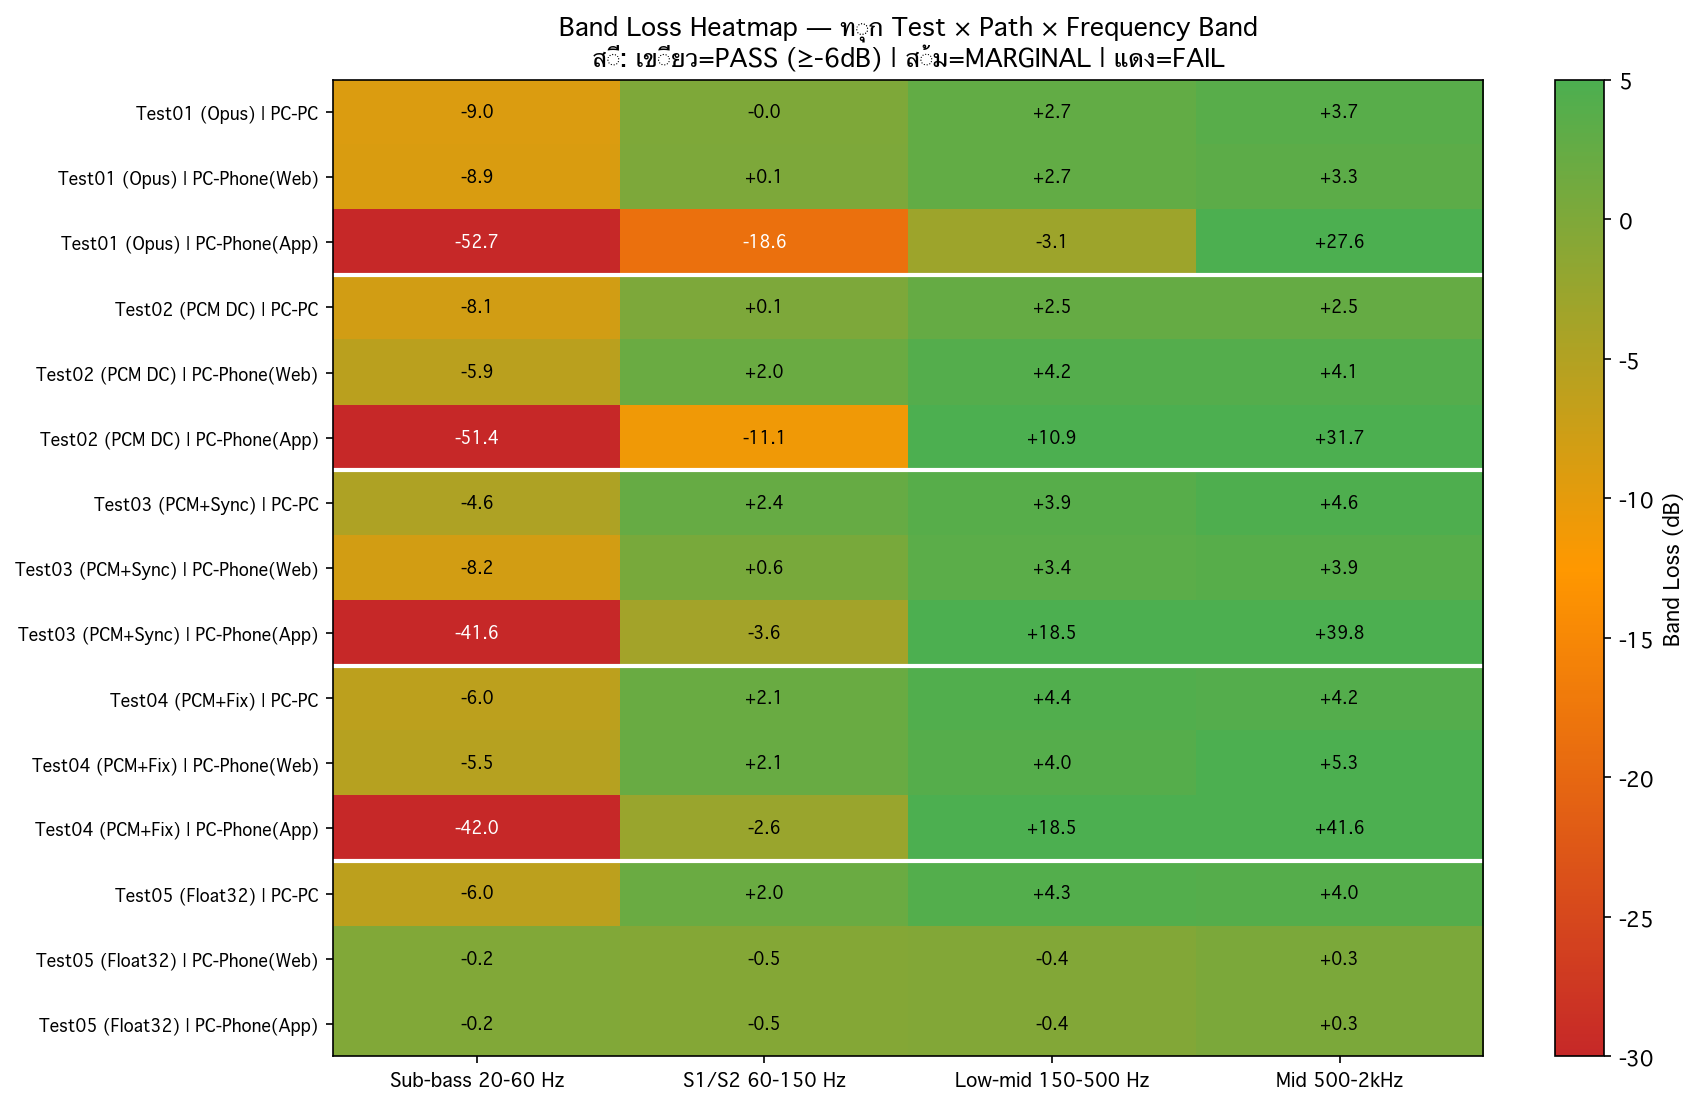

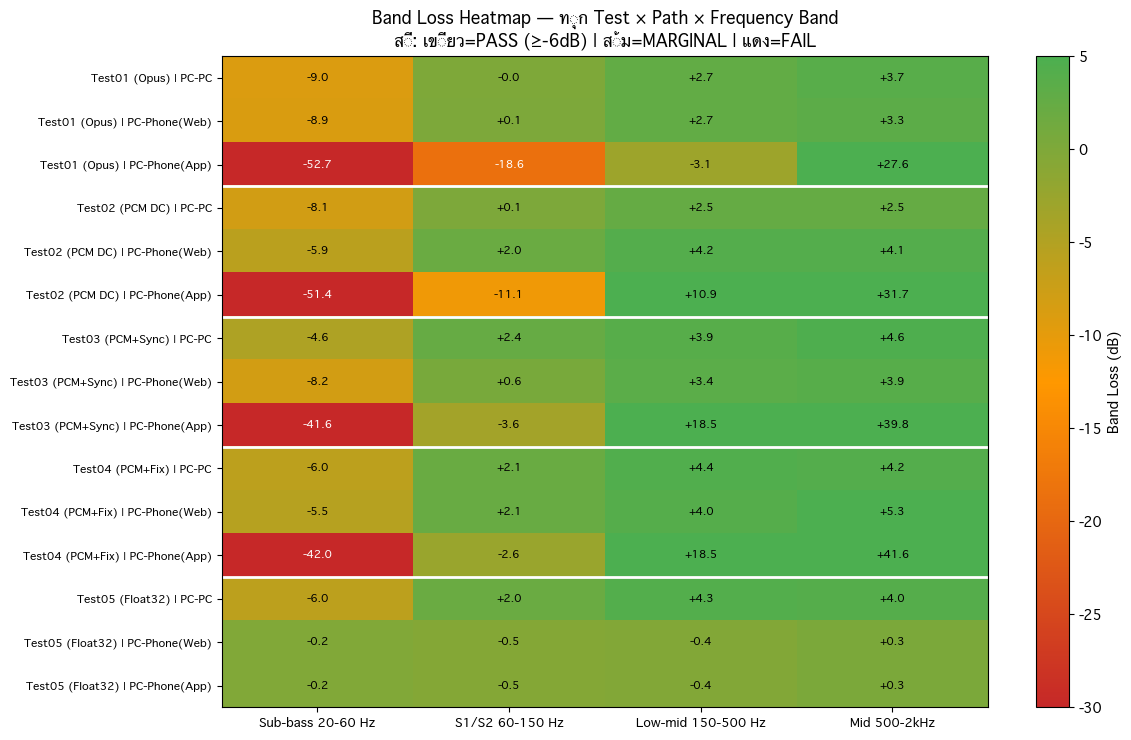

✅ result_heatmap.png saved


In [36]:
# Cell 3 — Heatmap: Band Loss ครบทุก band × Test × Path
n_tests = len(test_labels)
n_paths = len(PATHS)
n_bands = len(BANDS)

row_labels = []
loss_matrix = []
for tlabel in test_labels:
    for plabel in PATHS:
        v = results.get(tlabel, {}).get(plabel, None)
        if v is not None:
            row_labels.append(f'{tlabel.replace(chr(10)," ")} | {plabel}')
            loss_matrix.append([v.get(lo, np.nan) for _, lo, _ in BANDS])
        else:
            row_labels.append(f'{tlabel.replace(chr(10)," ")} | {plabel}')
            loss_matrix.append([np.nan] * n_bands)

Z = np.array(loss_matrix)
col_labels = [b[0].replace(chr(10),' ') for b in BANDS]

fig, ax = plt.subplots(figsize=(12, max(6, len(row_labels)*0.5)))
cmap = mcolors.LinearSegmentedColormap.from_list('rg', ['#C62828','#FF9800','#4CAF50'])
im = ax.imshow(Z, cmap=cmap, vmin=-30, vmax=5, aspect='auto')

for i in range(len(row_labels)):
    for j in range(n_bands):
        val = Z[i, j]
        if not np.isnan(val):
            txt = f'{val:+.1f}'
            color = 'white' if val < -15 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color, fontweight='bold')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='gray')

ax.set_xticks(range(n_bands))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)
plt.colorbar(im, ax=ax, label='Band Loss (dB)')
ax.set_title('Band Loss Heatmap — ทุก Test × Path × Frequency Band\n'
             'สี: เขียว=PASS (≥-6dB) | ส้ม=MARGINAL | แดง=FAIL',
             fontsize=12, fontweight='bold')

# วาดเส้นแบ่ง test groups
for i in range(n_paths, len(row_labels), n_paths):
    ax.axhline(i - 0.5, color='white', lw=2)

plt.tight_layout()
plt.savefig('result_heatmap.png', dpi=150, bbox_inches='tight')
from IPython.display import Image as _Img, display as _disp
_disp(_Img(filename='result_heatmap.png'))
plt.show()
print('✅ result_heatmap.png saved')


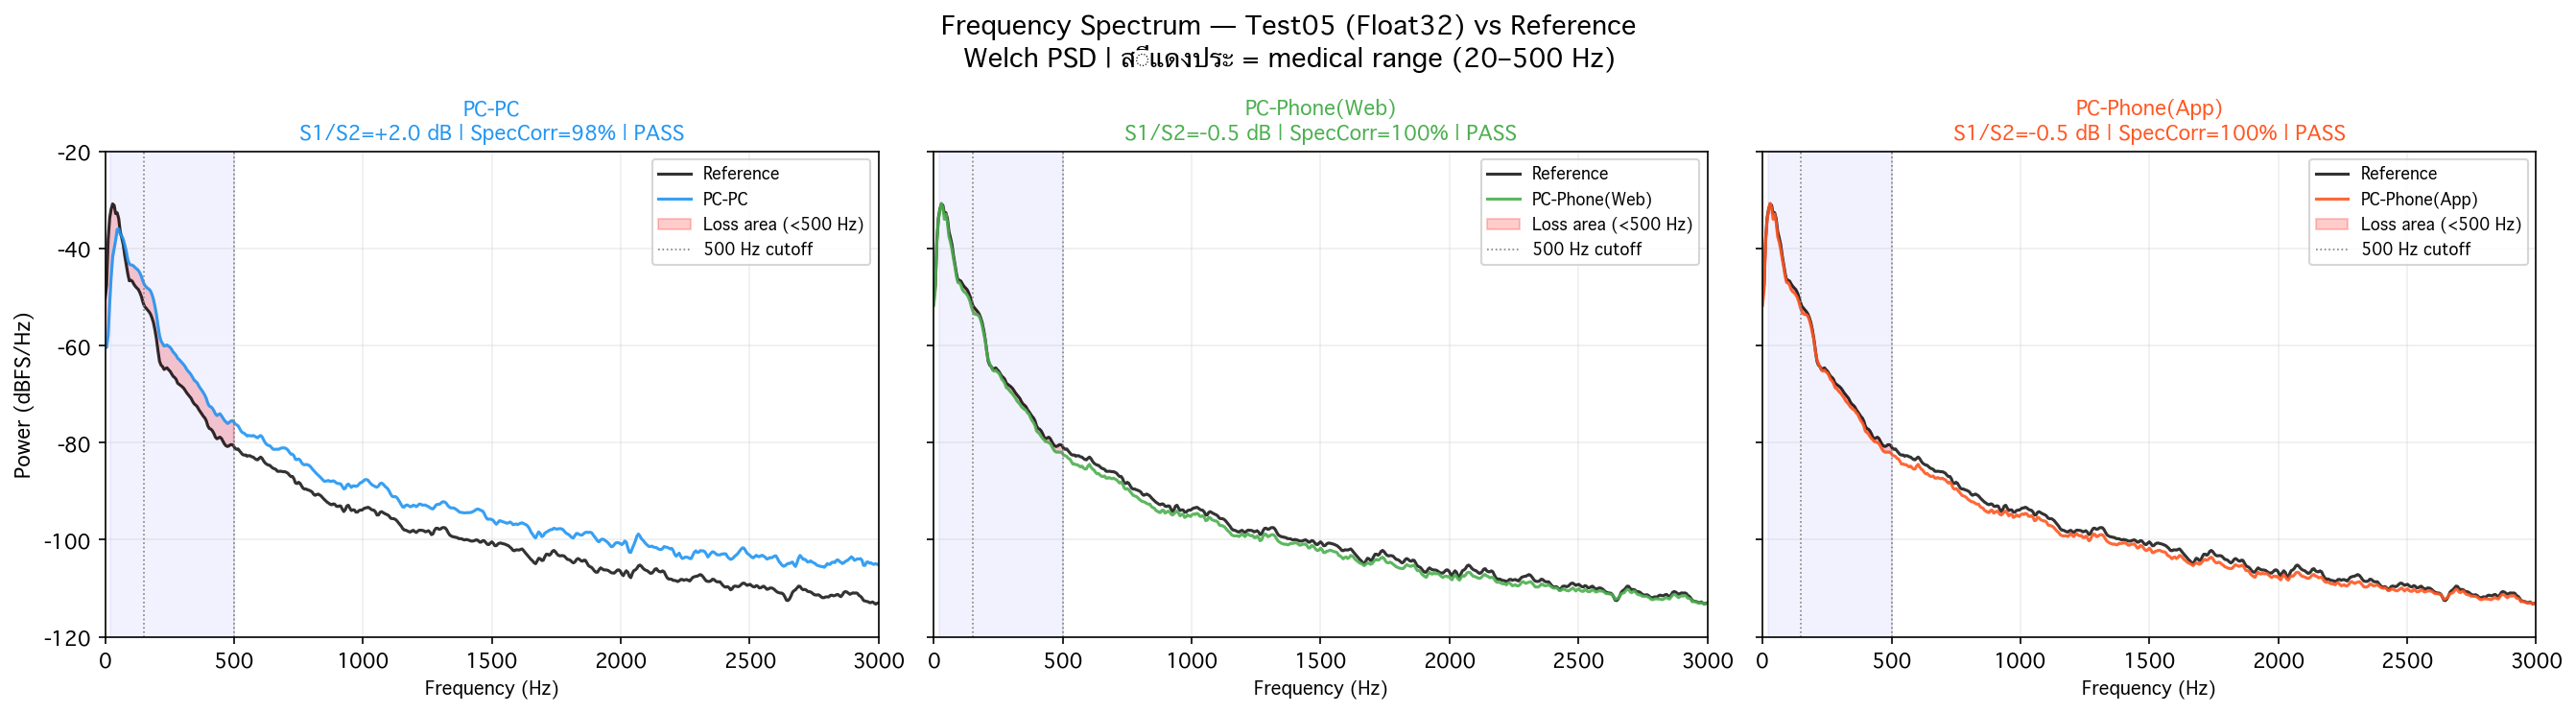

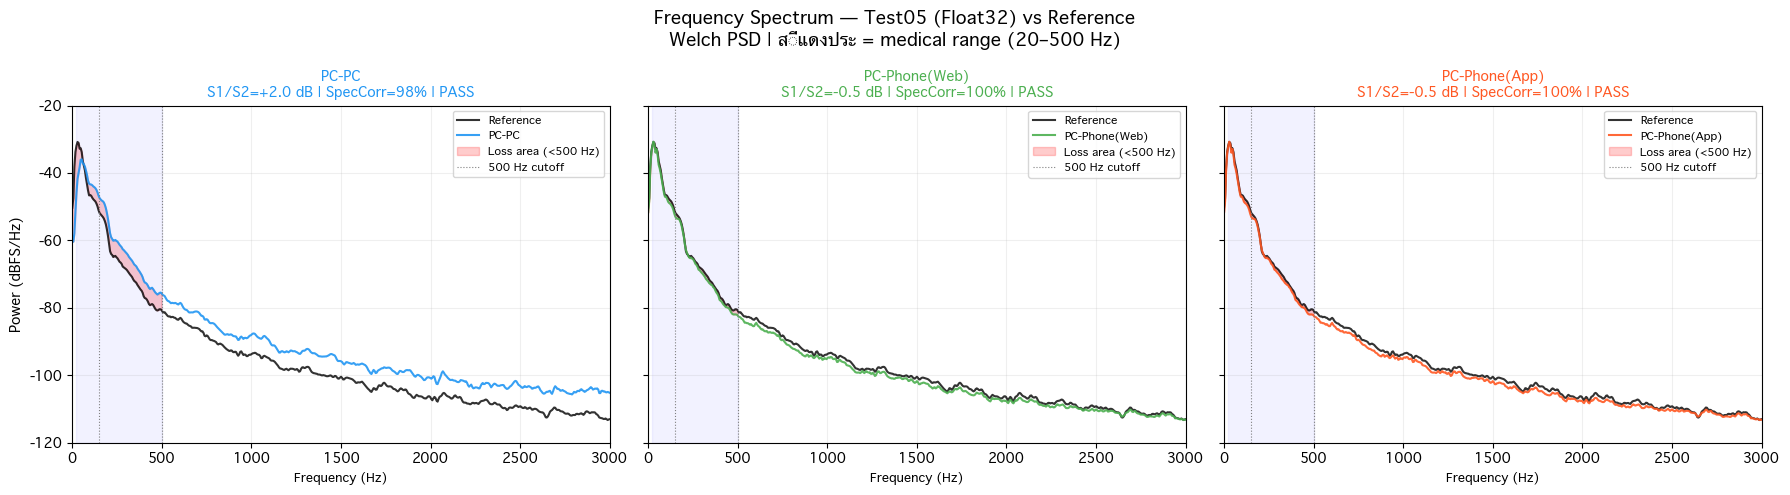

✅ result_spectrum.png saved


In [37]:
# Cell 4 — Frequency Spectrum (Welch PSD): Test05 vs Reference
latest_test = list(TESTS.keys())[-1]
available_paths = [p for p in PATHS if p in data.get(latest_test, {})]

fig, axes = plt.subplots(1, len(available_paths), figsize=(6*len(available_paths), 5), sharey=True)
fig.suptitle(f'Frequency Spectrum — {latest_test.replace(chr(10)," ")} vs Reference\n'
             f'Welch PSD | สีแดงประ = medical range (20–500 Hz)',
             fontsize=13, fontweight='bold')
if len(available_paths) == 1: axes = [axes]

for ax, plabel, pcolor in zip(axes, available_paths, PATH_COLORS):
    f_ref, p_ref = psd(ref_audio)
    f_rec, p_rec = psd(data[latest_test][plabel]['aligned'])
    ax.plot(f_ref, p_ref, color='black', lw=1.5, alpha=0.8, label='Reference')
    ax.plot(f_rec, p_rec, color=pcolor,  lw=1.5, alpha=0.9, label=plabel)
    ax.fill_between(f_rec, p_ref, p_rec, where=(f_rec < 500),
                    alpha=0.2, color='red', label='Loss area (<500 Hz)')
    ax.axvspan(20, 500, alpha=0.05, color='blue')
    ax.axvline(150, color='gray', lw=0.8, ls=':')
    ax.axvline(500, color='gray', lw=0.8, ls=':', label='500 Hz cutoff')
    s1s2 = results.get(latest_test, {}).get(plabel, {}).get(60, float('nan'))
    snr  = results.get(latest_test, {}).get(plabel, {}).get('spec_corr', float('nan'))
    verdict = 'PASS' if s1s2 >= MEDICAL_THRESHOLD_DB else 'FAIL'
    ax.set_title(f'{plabel}\nS1/S2={s1s2:+.1f} dB | SpecCorr={snr:.0f}% | {verdict}',
                 fontsize=10, fontweight='bold', color=pcolor)
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.set_xlim(0, 3000)
    ax.set_ylim(-120, -20)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    if ax == axes[0]: ax.set_ylabel('Power (dBFS/Hz)', fontsize=10)

plt.tight_layout()
plt.savefig('result_spectrum.png', dpi=150, bbox_inches='tight')
from IPython.display import Image as _Img, display as _disp
_disp(_Img(filename='result_spectrum.png'))
plt.show()
print('✅ result_spectrum.png saved')


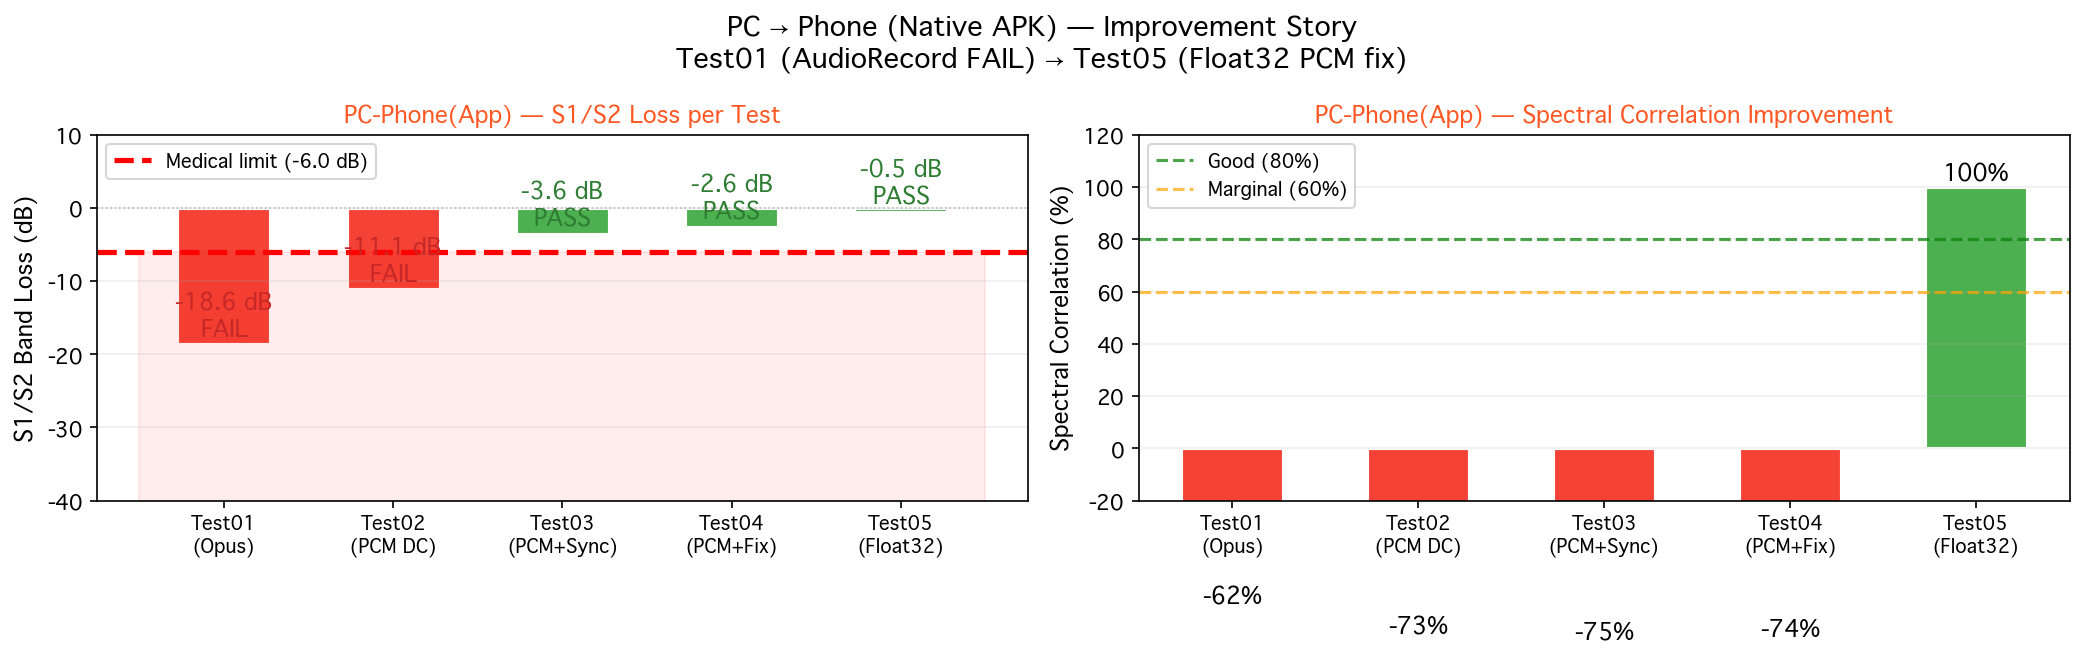

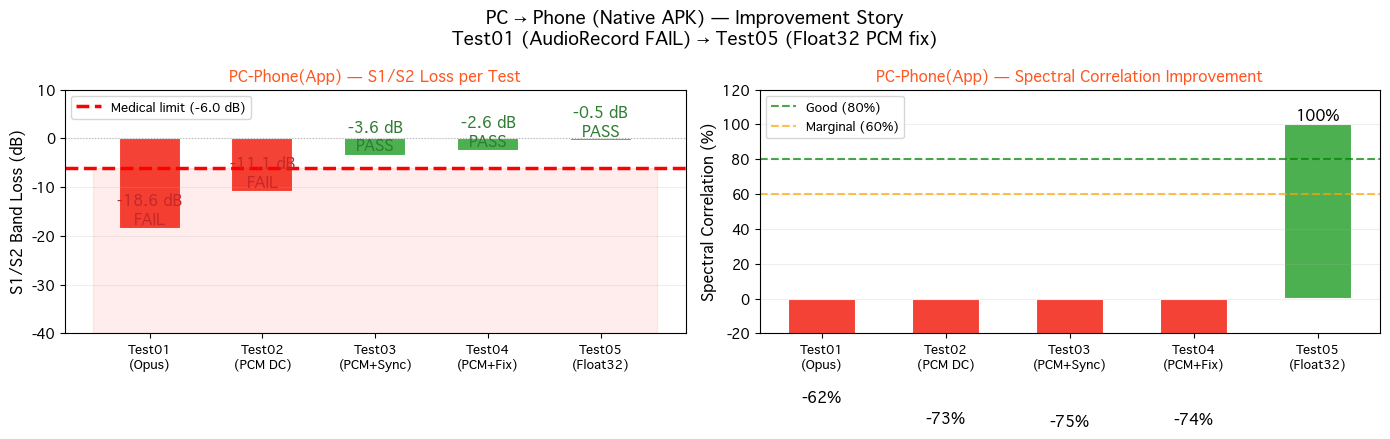

✅ result_improvement.png saved


In [38]:
# Cell 5 — App Path Improvement Story: Test01 → Test05
app_path = 'PC-Phone(App)'
s1s2_vals, s1s2_tests, snr_vals_app = [], [], []
for tlabel in test_labels:
    v = results.get(tlabel, {}).get(app_path, {}).get(60, None)
    if v is not None:
        s1s2_vals.append(v)
        s1s2_tests.append(tlabel)
        snr_vals_app.append(results[tlabel][app_path].get('spec_corr', np.nan))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PC → Phone (Native APK) — Improvement Story\n'
             f'Test01 (AudioRecord FAIL) → Test05 (Float32 PCM fix)',
             fontsize=13, fontweight='bold')

bar_colors = ['#4CAF50' if v >= MEDICAL_THRESHOLD_DB else '#F44336' for v in s1s2_vals]
bars = ax1.bar(range(len(s1s2_tests)), s1s2_vals, color=bar_colors, edgecolor='white', lw=1.5, width=0.55)
ax1.axhline(MEDICAL_THRESHOLD_DB, color='red', lw=2.5, ls='--', label=f'Medical limit ({MEDICAL_THRESHOLD_DB} dB)')
ax1.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.5)
ax1.fill_between([-0.5, len(s1s2_tests)-0.5], [MEDICAL_THRESHOLD_DB]*2, [-40]*2, alpha=0.07, color='red')
for bar, val in zip(bars, s1s2_vals):
    verdict = 'PASS' if val >= MEDICAL_THRESHOLD_DB else 'FAIL'
    color = '#2E7D32' if val >= MEDICAL_THRESHOLD_DB else '#C62828'
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
             f'{val:+.1f} dB\n{verdict}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=color)
ax1.set_xticks(range(len(s1s2_tests)))
ax1.set_xticklabels([t.replace(chr(10),'\n') for t in s1s2_tests], fontsize=9)
ax1.set_ylabel('S1/S2 Band Loss (dB)', fontsize=11)
ax1.set_title(f'{app_path} — S1/S2 Loss per Test', fontsize=11, fontweight='bold', color='#FF5722')
ax1.legend(fontsize=9)
ax1.set_ylim(-40, 10)
ax1.grid(True, alpha=0.2, axis='y')

# SNR improvement
snr_colors = ['#4CAF50' if v >= 80 else ('#FF9800' if v >= 60 else '#F44336') for v in snr_vals_app]
bars2 = ax2.bar(range(len(s1s2_tests)), snr_vals_app, color=snr_colors, edgecolor='white', lw=1.5, width=0.55)
ax2.axhline(80, color='green', lw=1.5, ls='--', label='Good (80%)', alpha=0.7)
ax2.axhline(60, color='orange', lw=1.5, ls='--', label='Marginal (60%)', alpha=0.7)
for bar, val in zip(bars2, snr_vals_app):
    if not np.isnan(val):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(s1s2_tests)))
ax2.set_xticklabels([t.replace(chr(10),'\n') for t in s1s2_tests], fontsize=9)
ax2.set_ylabel('Spectral Correlation (%)', fontsize=11)
ax2.set_title(f'{app_path} — Spectral Correlation Improvement', fontsize=11, fontweight='bold', color='#FF5722')
ax2.legend(fontsize=9)
ax2.set_ylim(-20, 120)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('result_improvement.png', dpi=150, bbox_inches='tight')
from IPython.display import Image as _Img, display as _disp
_disp(_Img(filename='result_improvement.png'))
plt.show()
print('✅ result_improvement.png saved')


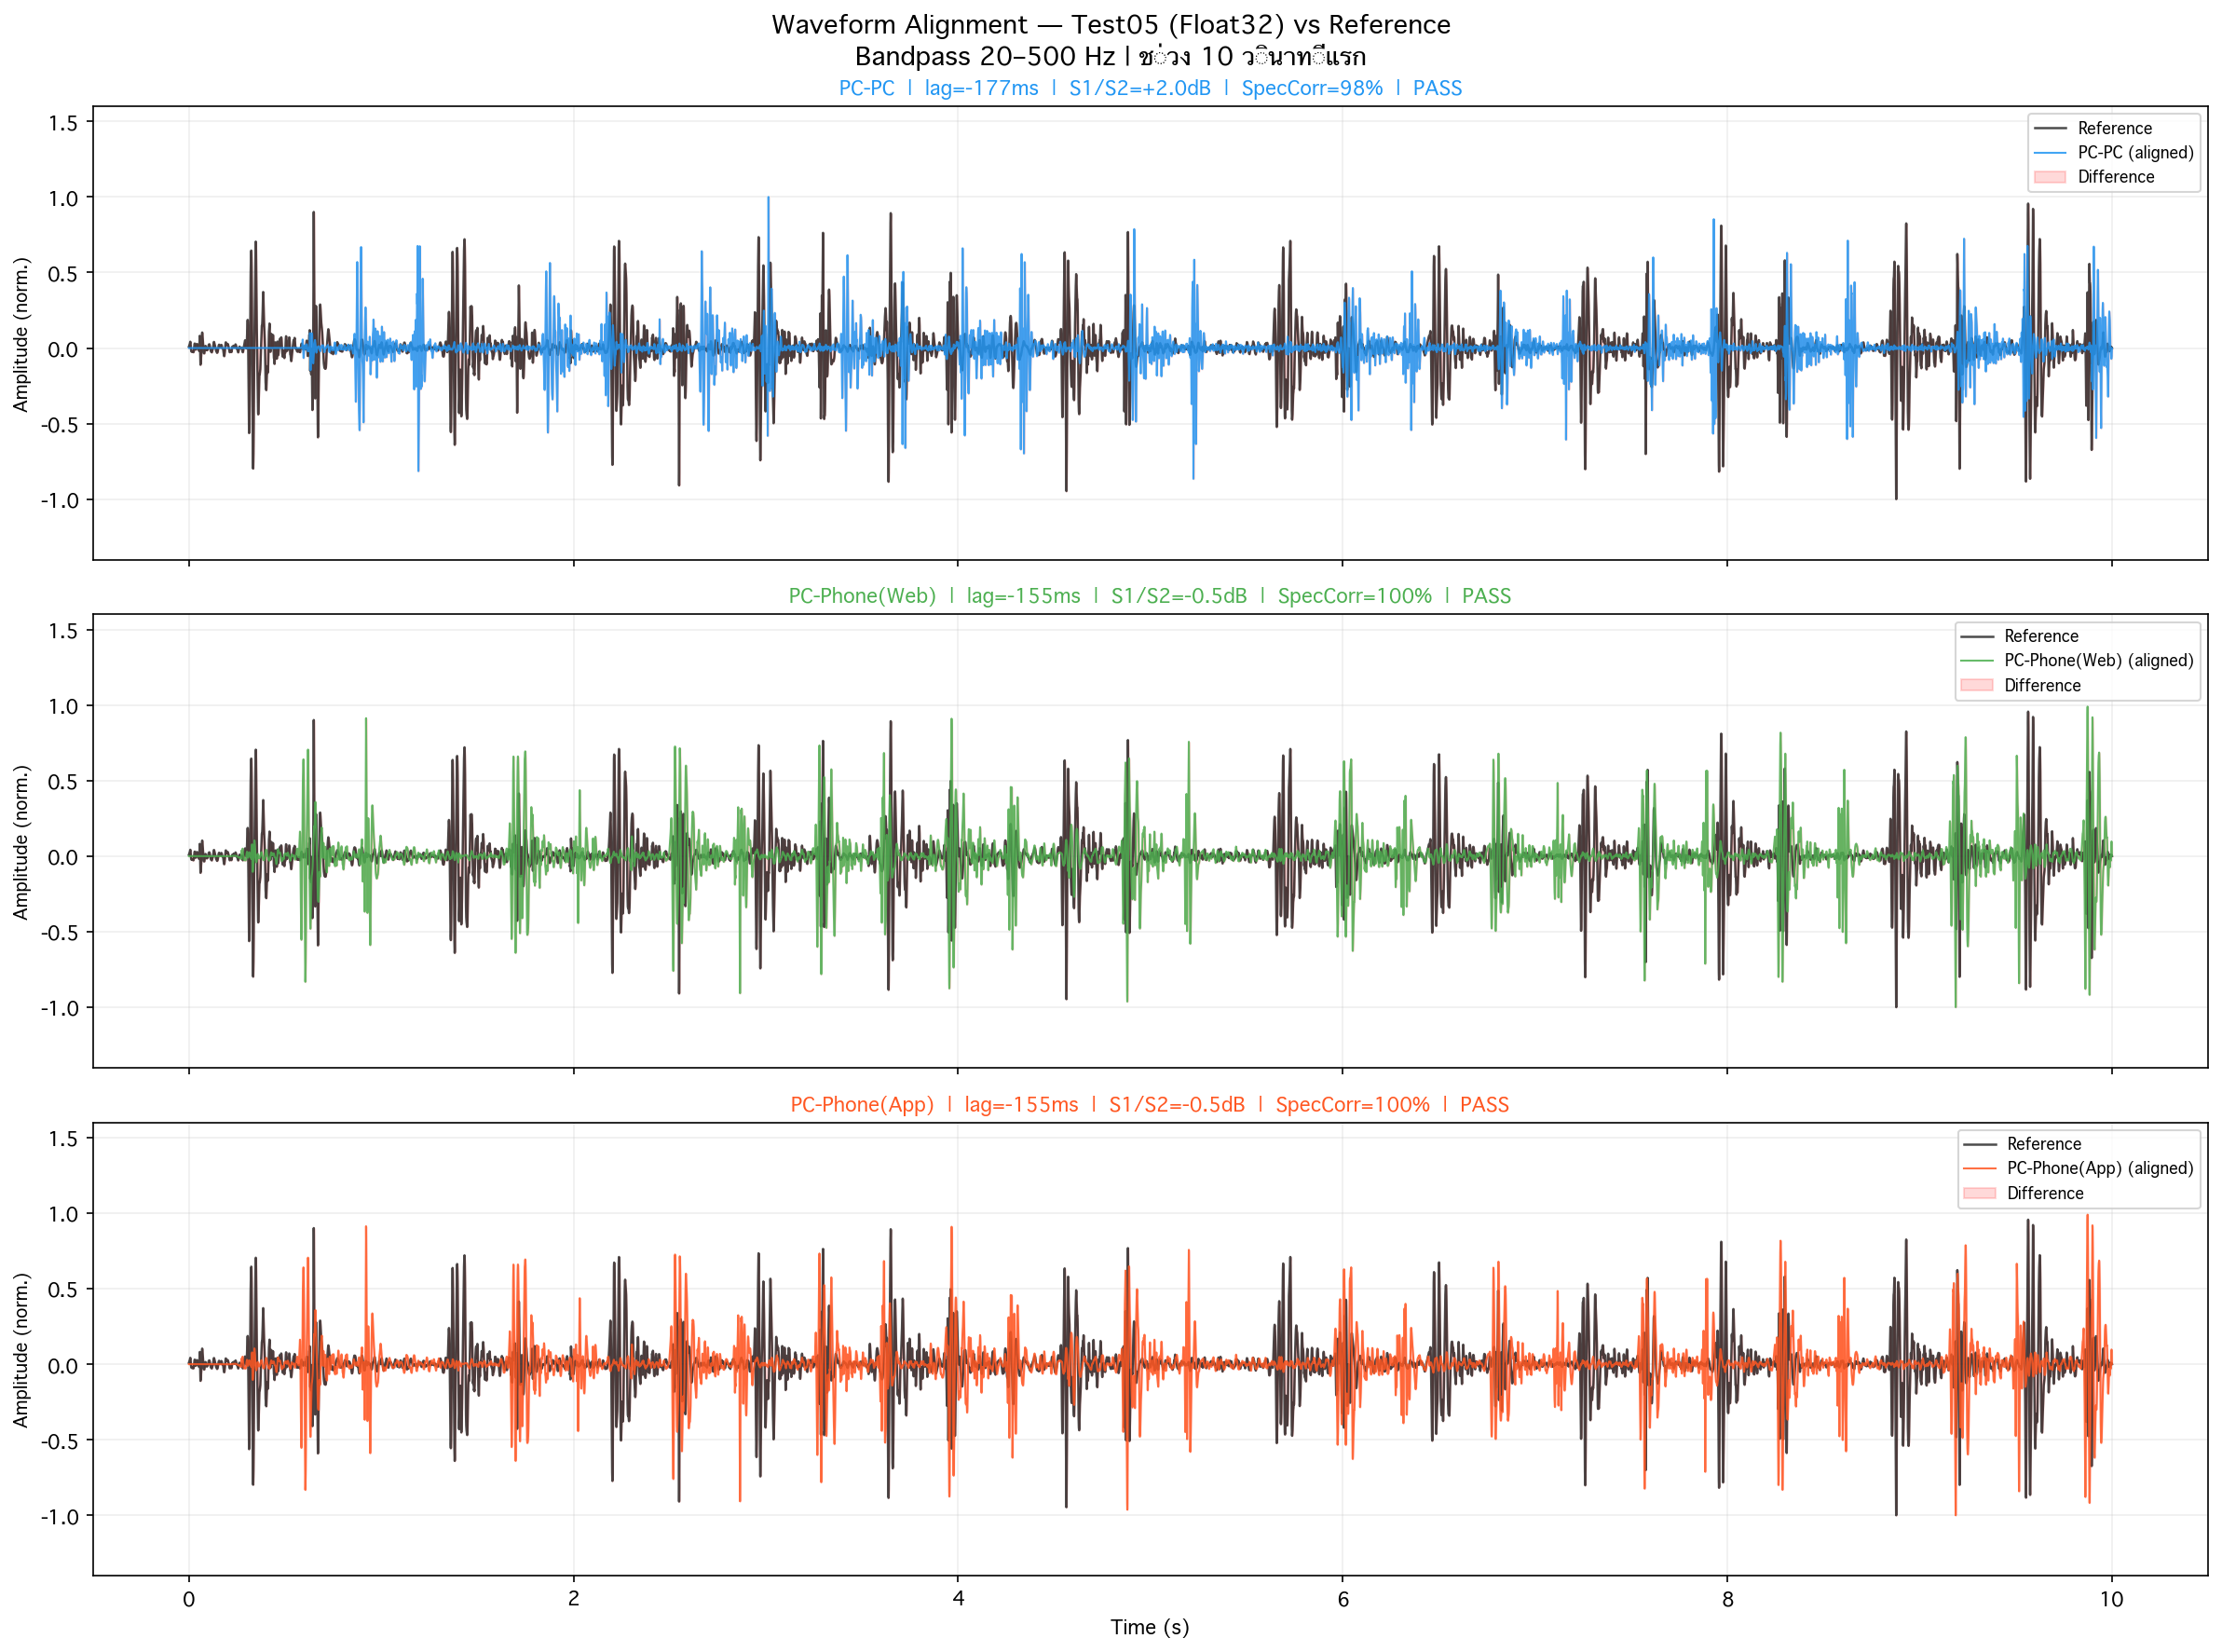

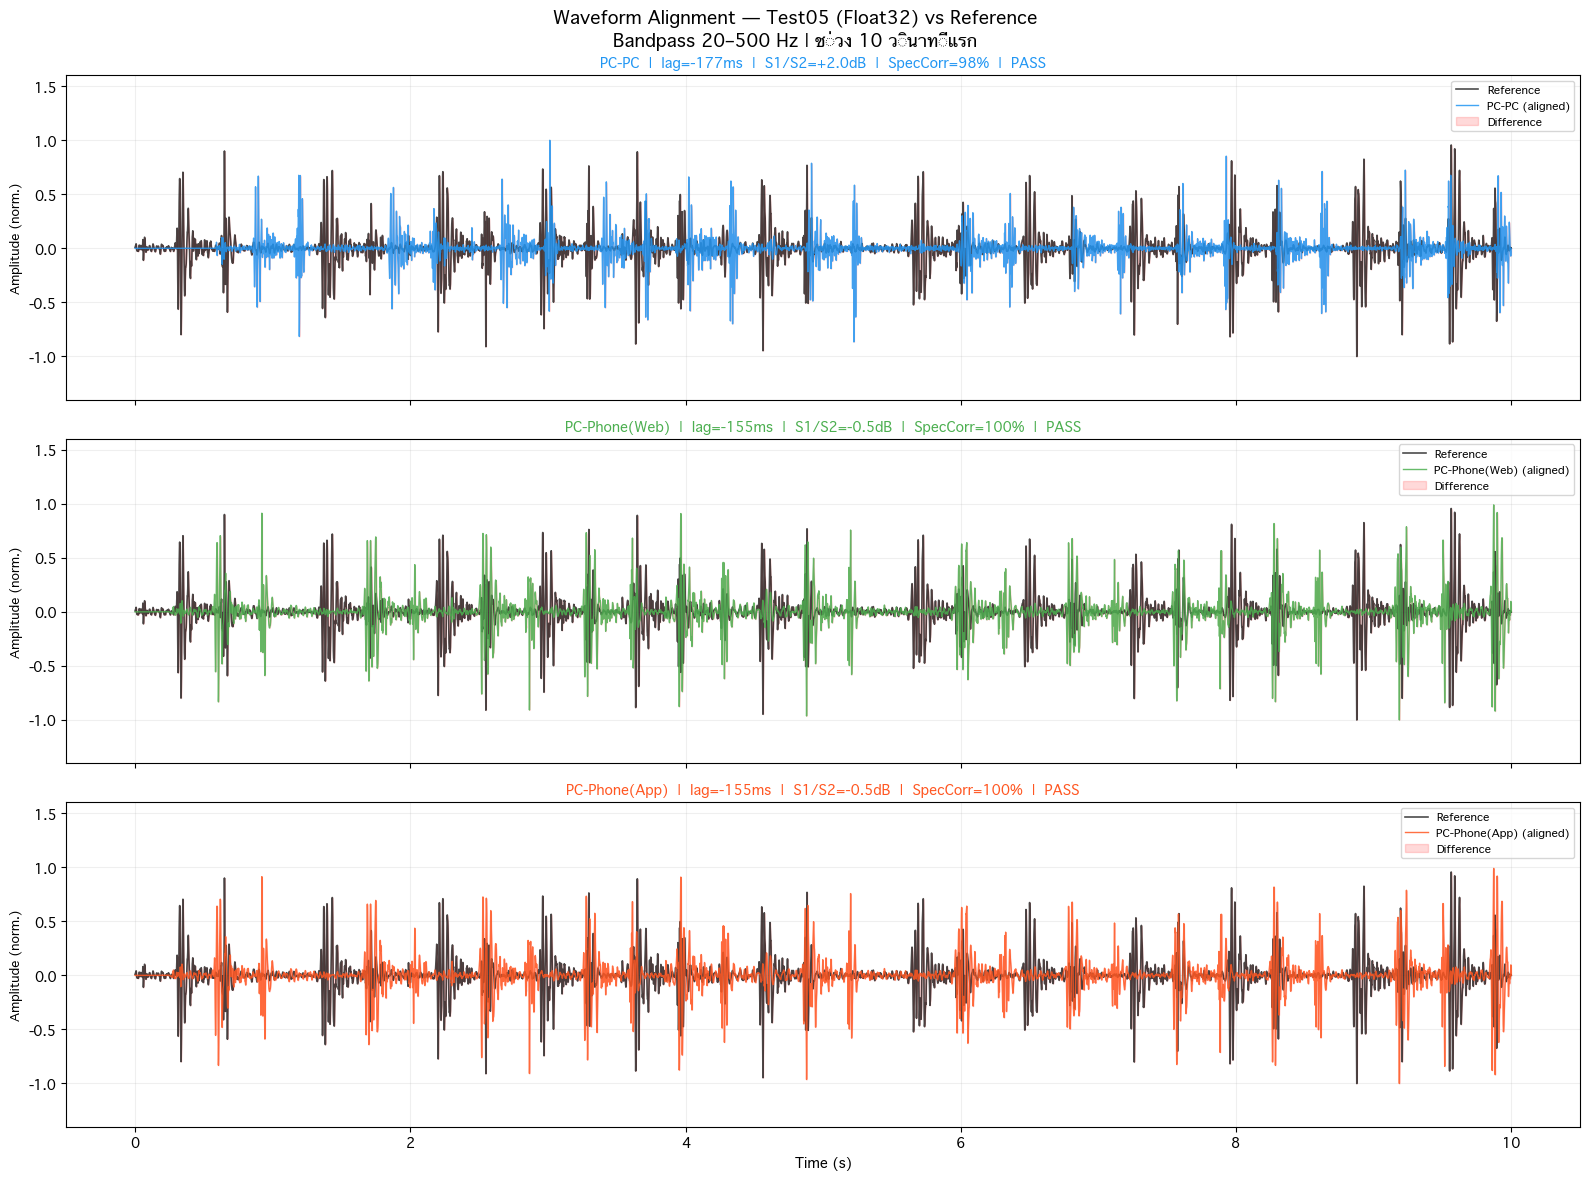

✅ result_waveform.png saved


In [39]:
# Cell 6 — Waveform Alignment Visualization (latest test)
latest_test = list(TESTS.keys())[-1]
available_paths = [p for p in PATHS if p in data.get(latest_test, {})]

fig, axes = plt.subplots(len(available_paths), 1, figsize=(16, 4*len(available_paths)), sharex=True)
fig.suptitle(f'Waveform Alignment — {latest_test.replace(chr(10)," ")} vs Reference\n'
             f'Bandpass 20–500 Hz | ช่วง 10 วินาทีแรก',
             fontsize=13, fontweight='bold')
if len(available_paths) == 1: axes = [axes]

sos_bp = make_sos_bandpass(20, 500)  # SOS format — stable on long signals
SHOW_SEC = 10
t_ref = np.linspace(0, SHOW_SEC, int(SR * SHOW_SEC))

for ax, plabel, pcolor in zip(axes, available_paths, PATH_COLORS):
    ref_bp = scipy_signal.sosfiltfilt(sos_bp, ref_audio[:len(t_ref)])
    aln    = data[latest_test][plabel]['aligned']
    rec_bp = scipy_signal.sosfiltfilt(sos_bp, aln[:len(t_ref)])
    ref_n  = ref_bp / (np.abs(ref_bp).max() + 1e-9)
    rec_n  = rec_bp / (np.abs(rec_bp).max() + 1e-9)
    ax.plot(t_ref, ref_n, color='black', lw=1.2, alpha=0.7, label='Reference')
    ax.plot(t_ref, rec_n, color=pcolor,  lw=1.0, alpha=0.85, label=f'{plabel} (aligned)')
    ax.fill_between(t_ref, ref_n, rec_n, alpha=0.15, color='red', label='Difference')
    lag_ms = data[latest_test][plabel]['lag'] / SR * 1000
    s1s2   = results[latest_test][plabel].get(60, float('nan'))
    snr    = results[latest_test][plabel].get('spec_corr', float('nan'))
    verdict = 'PASS' if s1s2 >= MEDICAL_THRESHOLD_DB else 'FAIL'
    ax.set_title(f'{plabel}  |  lag={lag_ms:+.0f}ms  |  S1/S2={s1s2:+.1f}dB  |  SpecCorr={snr:.0f}%  |  {verdict}',
                 fontsize=10, fontweight='bold', color=pcolor)
    ax.set_ylabel('Amplitude (norm.)', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(-1.4, 1.6)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()
plt.savefig('result_waveform.png', dpi=150, bbox_inches='tight')
from IPython.display import Image as _Img, display as _disp
_disp(_Img(filename='result_waveform.png'))
plt.show()
print('✅ result_waveform.png saved')


In [40]:
# Cell 7 — Final Verdict Report
THRESHOLD = MEDICAL_THRESHOLD_DB

def verdict_icon(db):
    if db >= THRESHOLD: return '✅ PASS'
    if db >= -15:       return '⚠️  MARGINAL'
    return '❌ FAIL'

tech_map = {
    'Test01\n(Opus)':       'WebRTC Opus (std)',
    'Test02\n(PCM DC)':     'DataChannel PCM',
    'Test03\n(PCM+Sync)':   'PCM + Auto-sync',
    'Test04\n(PCM+Fix)':    'PCM + Lifecycle fix',
    'Test05\n(Float32)':    'PCM + Float32 binary fix',
}

print()
print('=' * 100)
print('  WebRTC Heart Sound Quality — Final Verdict Report')
print(f'  เกณฑ์: S1/S2 (60–150 Hz) loss ≤ {abs(THRESHOLD)} dB | Spectral Corr > 60%')
print('=' * 100)
header = f"  {'ชุดทดสอบ':<22} {'เทคโนโลยี':<28} {'PC→PC':>22} {'PC→Web':>22} {'PC→App':>22}"
print(header)
print('  ' + '-' * 98)

for tlabel in test_labels:
    tech = tech_map.get(tlabel, '')
    row  = f'  {tlabel.replace(chr(10)," "):<22} {tech:<28}'
    for plabel in PATHS:
        v = results.get(tlabel, {}).get(plabel, {})
        s1s2 = v.get(60, None)
        snr  = v.get('spec_corr', None)
        if s1s2 is not None:
            cell = f'{s1s2:+.1f}dB {verdict_icon(s1s2)} SC:{snr:.0f}%'
        else:
            cell = '— (no data)'
        row += f'  {cell:>22}'
    print(row)

print('  ' + '-' * 98)
print()

latest = list(TESTS.keys())[-1]
print(f'  สรุปผลล่าสุด ({latest.replace(chr(10)," ")})')
all_pass = True
for plabel in PATHS:
    v = results.get(latest, {}).get(plabel, {})
    s1s2 = v.get(60, None)
    snr  = v.get('spec_corr', None)
    if s1s2 is not None:
        icon = verdict_icon(s1s2)
        print(f'    {icon}  {plabel:<24}  S1/S2={s1s2:+.1f} dB  SpecCorr={snr:.0f}%')
        if s1s2 < THRESHOLD: all_pass = False
    else:
        print(f'    —  {plabel:<24}  (ไม่มีข้อมูล)')

print()
if all_pass:
    print('  🎉 ทุก path ผ่านเกณฑ์ทางการแพทย์แล้ว — พร้อมทดสอบกับ stethoscope จริง')
else:
    print('  ⚠️  บาง path ยังไม่ผ่าน')
print('=' * 100)



  WebRTC Heart Sound Quality — Final Verdict Report
  เกณฑ์: S1/S2 (60–150 Hz) loss ≤ 6.0 dB | Spectral Corr > 60%
  ชุดทดสอบ               เทคโนโลยี                                     PC→PC                 PC→Web                 PC→App
  --------------------------------------------------------------------------------------------------
  Test01 (Opus)          WebRTC Opus (std)               -0.0dB ✅ PASS SC:98%    +0.1dB ✅ PASS SC:98%  -18.6dB ❌ FAIL SC:-62%
  Test02 (PCM DC)        DataChannel PCM                 +0.1dB ✅ PASS SC:98%    +2.0dB ✅ PASS SC:98%  -11.1dB ⚠️  MARGINAL SC:-73%
  Test03 (PCM+Sync)      PCM + Auto-sync                 +2.4dB ✅ PASS SC:99%    +0.6dB ✅ PASS SC:98%   -3.6dB ✅ PASS SC:-75%
  Test04 (PCM+Fix)       PCM + Lifecycle fix             +2.1dB ✅ PASS SC:98%    +2.1dB ✅ PASS SC:99%   -2.6dB ✅ PASS SC:-74%
  Test05 (Float32)       PCM + Float32 binary fix        +2.0dB ✅ PASS SC:98%   -0.5dB ✅ PASS SC:100%   -0.5dB ✅ PASS SC:100%
  ----------------------